# Section 2: Data Exploration and Analysis
## Bank Marketing Dataset

**Dataset Source:** [UCI Machine Learning Repository - Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank-marketing)

**Objective:** This cell performs comprehensive exploratory data analysis (EDA) on the Bank Marketing dataset, covering:
1. Features Identification and Summary
2. Visual Data Exploration
3. Handling Missing Values
4. Statistical Characterization of Numerical Data

---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('../data/raw/bank-full.csv', sep=';')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns\n")


Dataset loaded: 45211 rows × 17 columns



In [2]:
# ======================================================================================
# REQUIREMENT 1: FEATURES IDENTIFICATION AND SUMMARY (Score: 6)
# ======================================================================================
print("=" * 120)
print(" REQUIREMENT 1: FEATURES IDENTIFICATION AND SUMMARY ".center(120, "="))
print("=" * 120)

# Generate comprehensive feature summary
summary_data = []
for column in df.columns:
    sample_value = df[column].dropna().iloc[0] if not df[column].dropna().empty else "N/A"
    summary_data.append({
        'Feature Name': column,
        'Data Type': str(df[column].dtype),
        'Total Values': len(df[column]),
        'Unique Values': df[column].nunique(),
        'Missing Values': df[column].isnull().sum(),
        'Missing %': round((df[column].isnull().sum() / len(df[column])) * 100, 2),
        'Sample Value': sample_value
    })

feature_summary = pd.DataFrame(summary_data)
print("\n📋 FEATURE SUMMARY TABLE:")
print("-" * 120)
display(feature_summary)

# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n{'=' * 120}")
print(f"📊 NUMERICAL FEATURES ({len(numerical_features)}): {', '.join(numerical_features)}")
print(f"📋 CATEGORICAL FEATURES ({len(categorical_features)}): {', '.join(categorical_features)}")
print(f"{'=' * 120}\n")


================================== REQUIREMENT 1: FEATURES IDENTIFICATION AND SUMMARY ==================================

📋 FEATURE SUMMARY TABLE:
------------------------------------------------------------------------------------------------------------------------


,Feature Name,Data Type,Total Values,Unique Values,Missing Values,Missing %,Sample Value
0,age,int64,45211,77,0,0.0,58
1,job,object,45211,12,0,0.0,management
2,marital,object,45211,3,0,0.0,married
3,education,object,45211,4,0,0.0,tertiary
4,default,object,45211,2,0,0.0,no
5,balance,int64,45211,7168,0,0.0,2143
6,housing,object,45211,2,0,0.0,yes
7,loan,object,45211,2,0,0.0,no
8,contact,object,45211,3,0,0.0,unknown
9,day,int64,45211,31,0,0.0,5



📊 NUMERICAL FEATURES (7): age, balance, day, duration, campaign, pdays, previous
📋 CATEGORICAL FEATURES (10): job, marital, education, default, housing, loan, contact, month, poutcome, y



======================================== REQUIREMENT 2: VISUAL DATA EXPLORATION ========================================

📊 2.1: Generating histograms for numerical features...


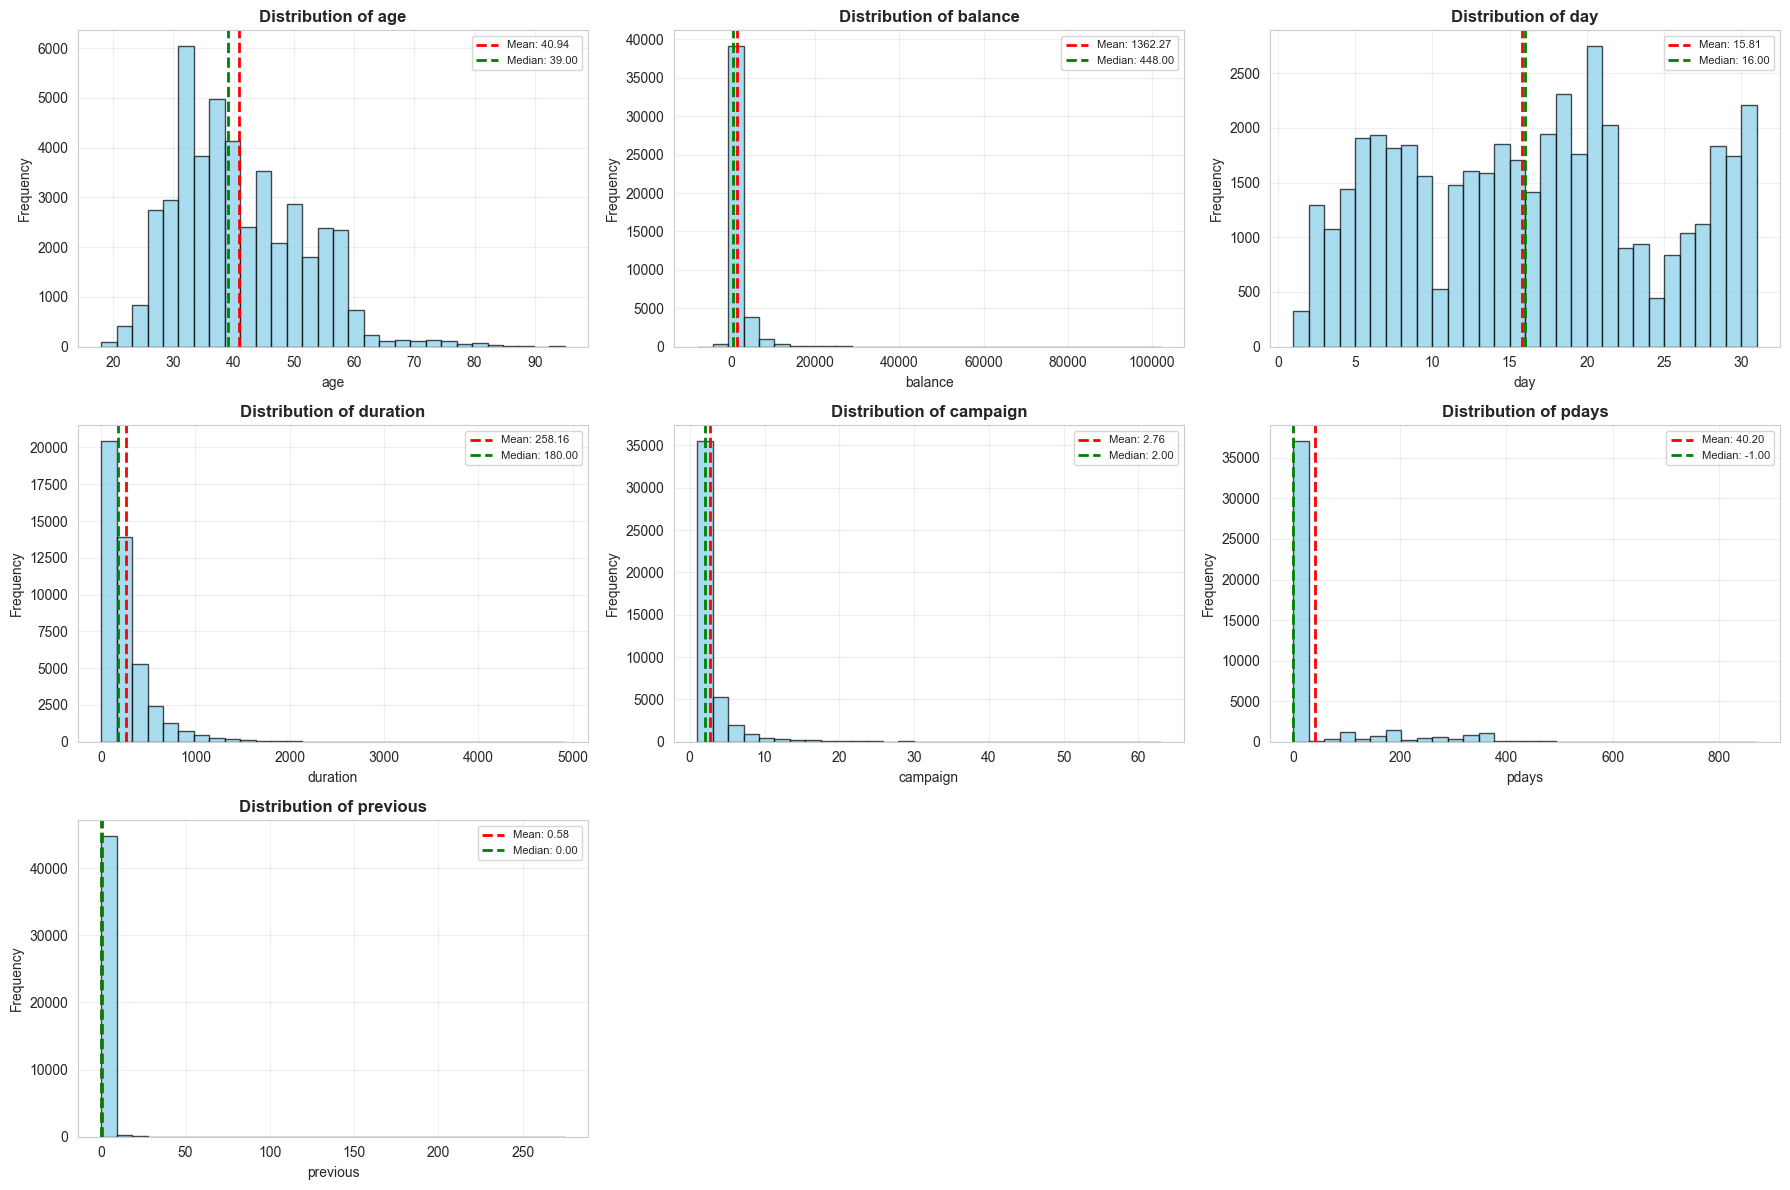

✅ Histograms completed!

📊 2.2: Generating bar graphs for categorical features...


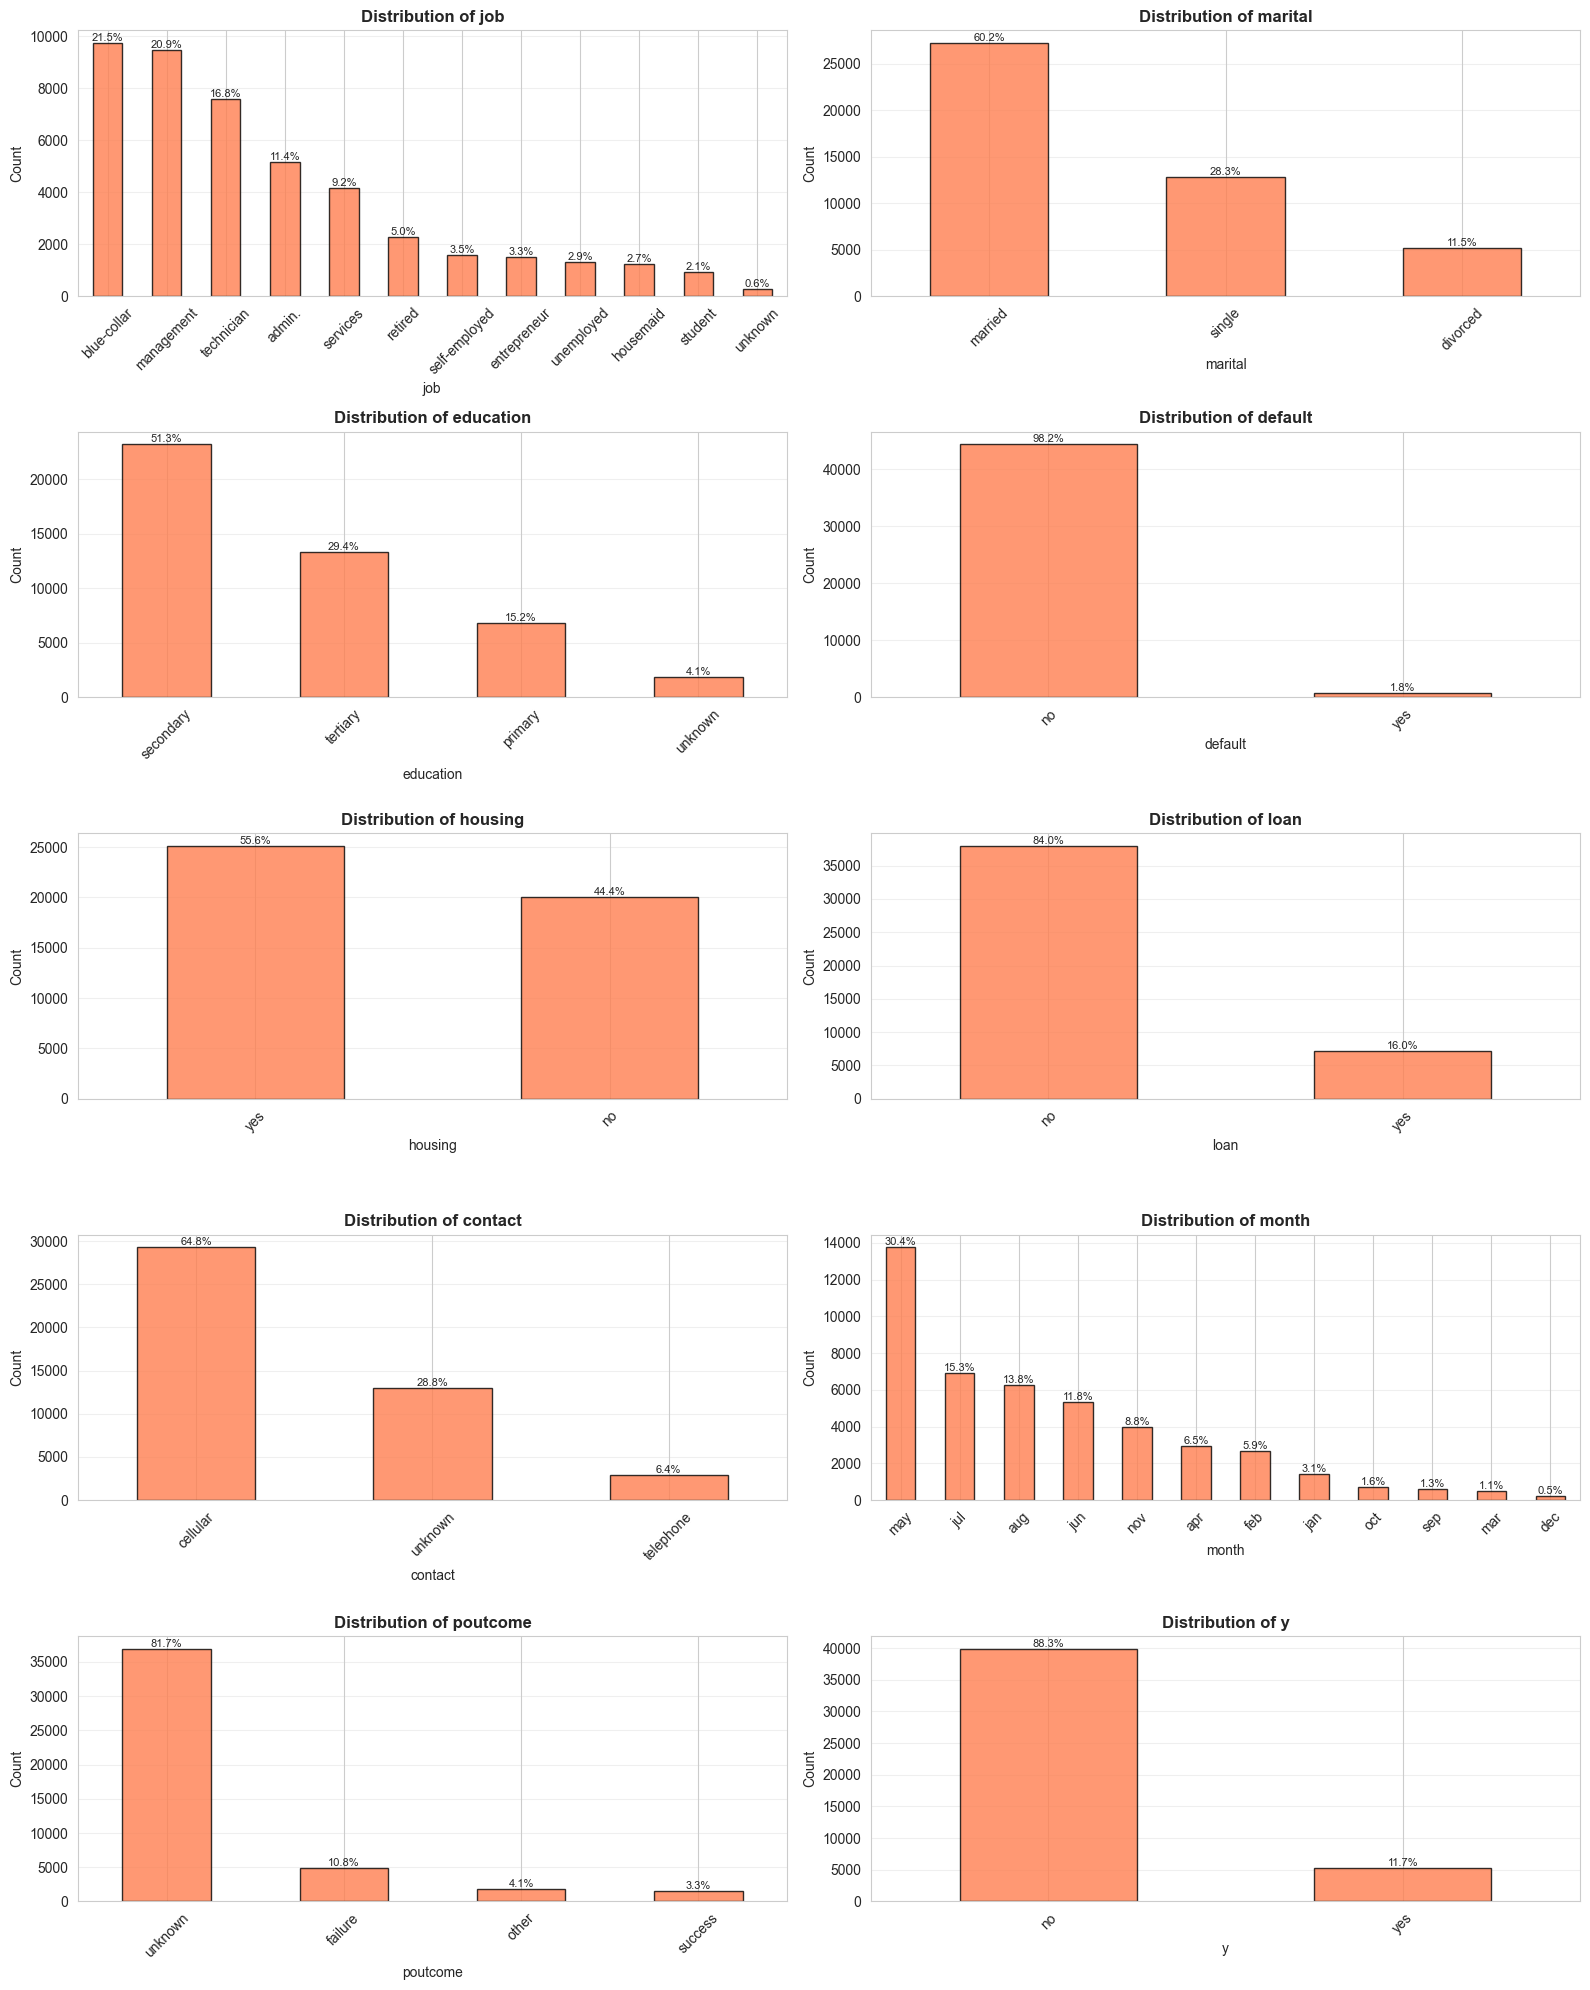

✅ Bar graphs completed!

📊 2.3: Generating correlation heatmap...


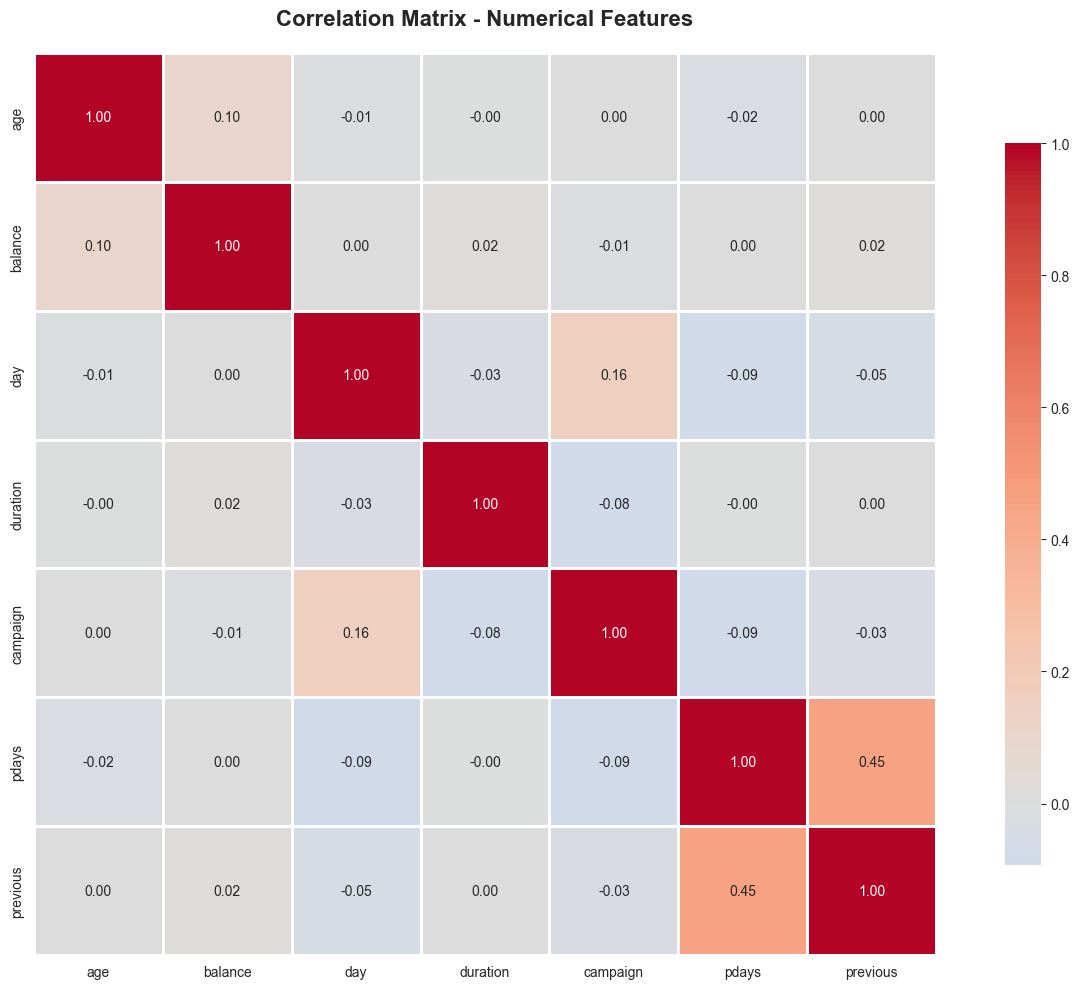


🔍 Highly Correlated Feature Pairs (|correlation| > 0.7):
No highly correlated pairs found (threshold: |0.7|)
✅ Correlation analysis completed!

📊 2.4: Generating box plots for outlier detection...


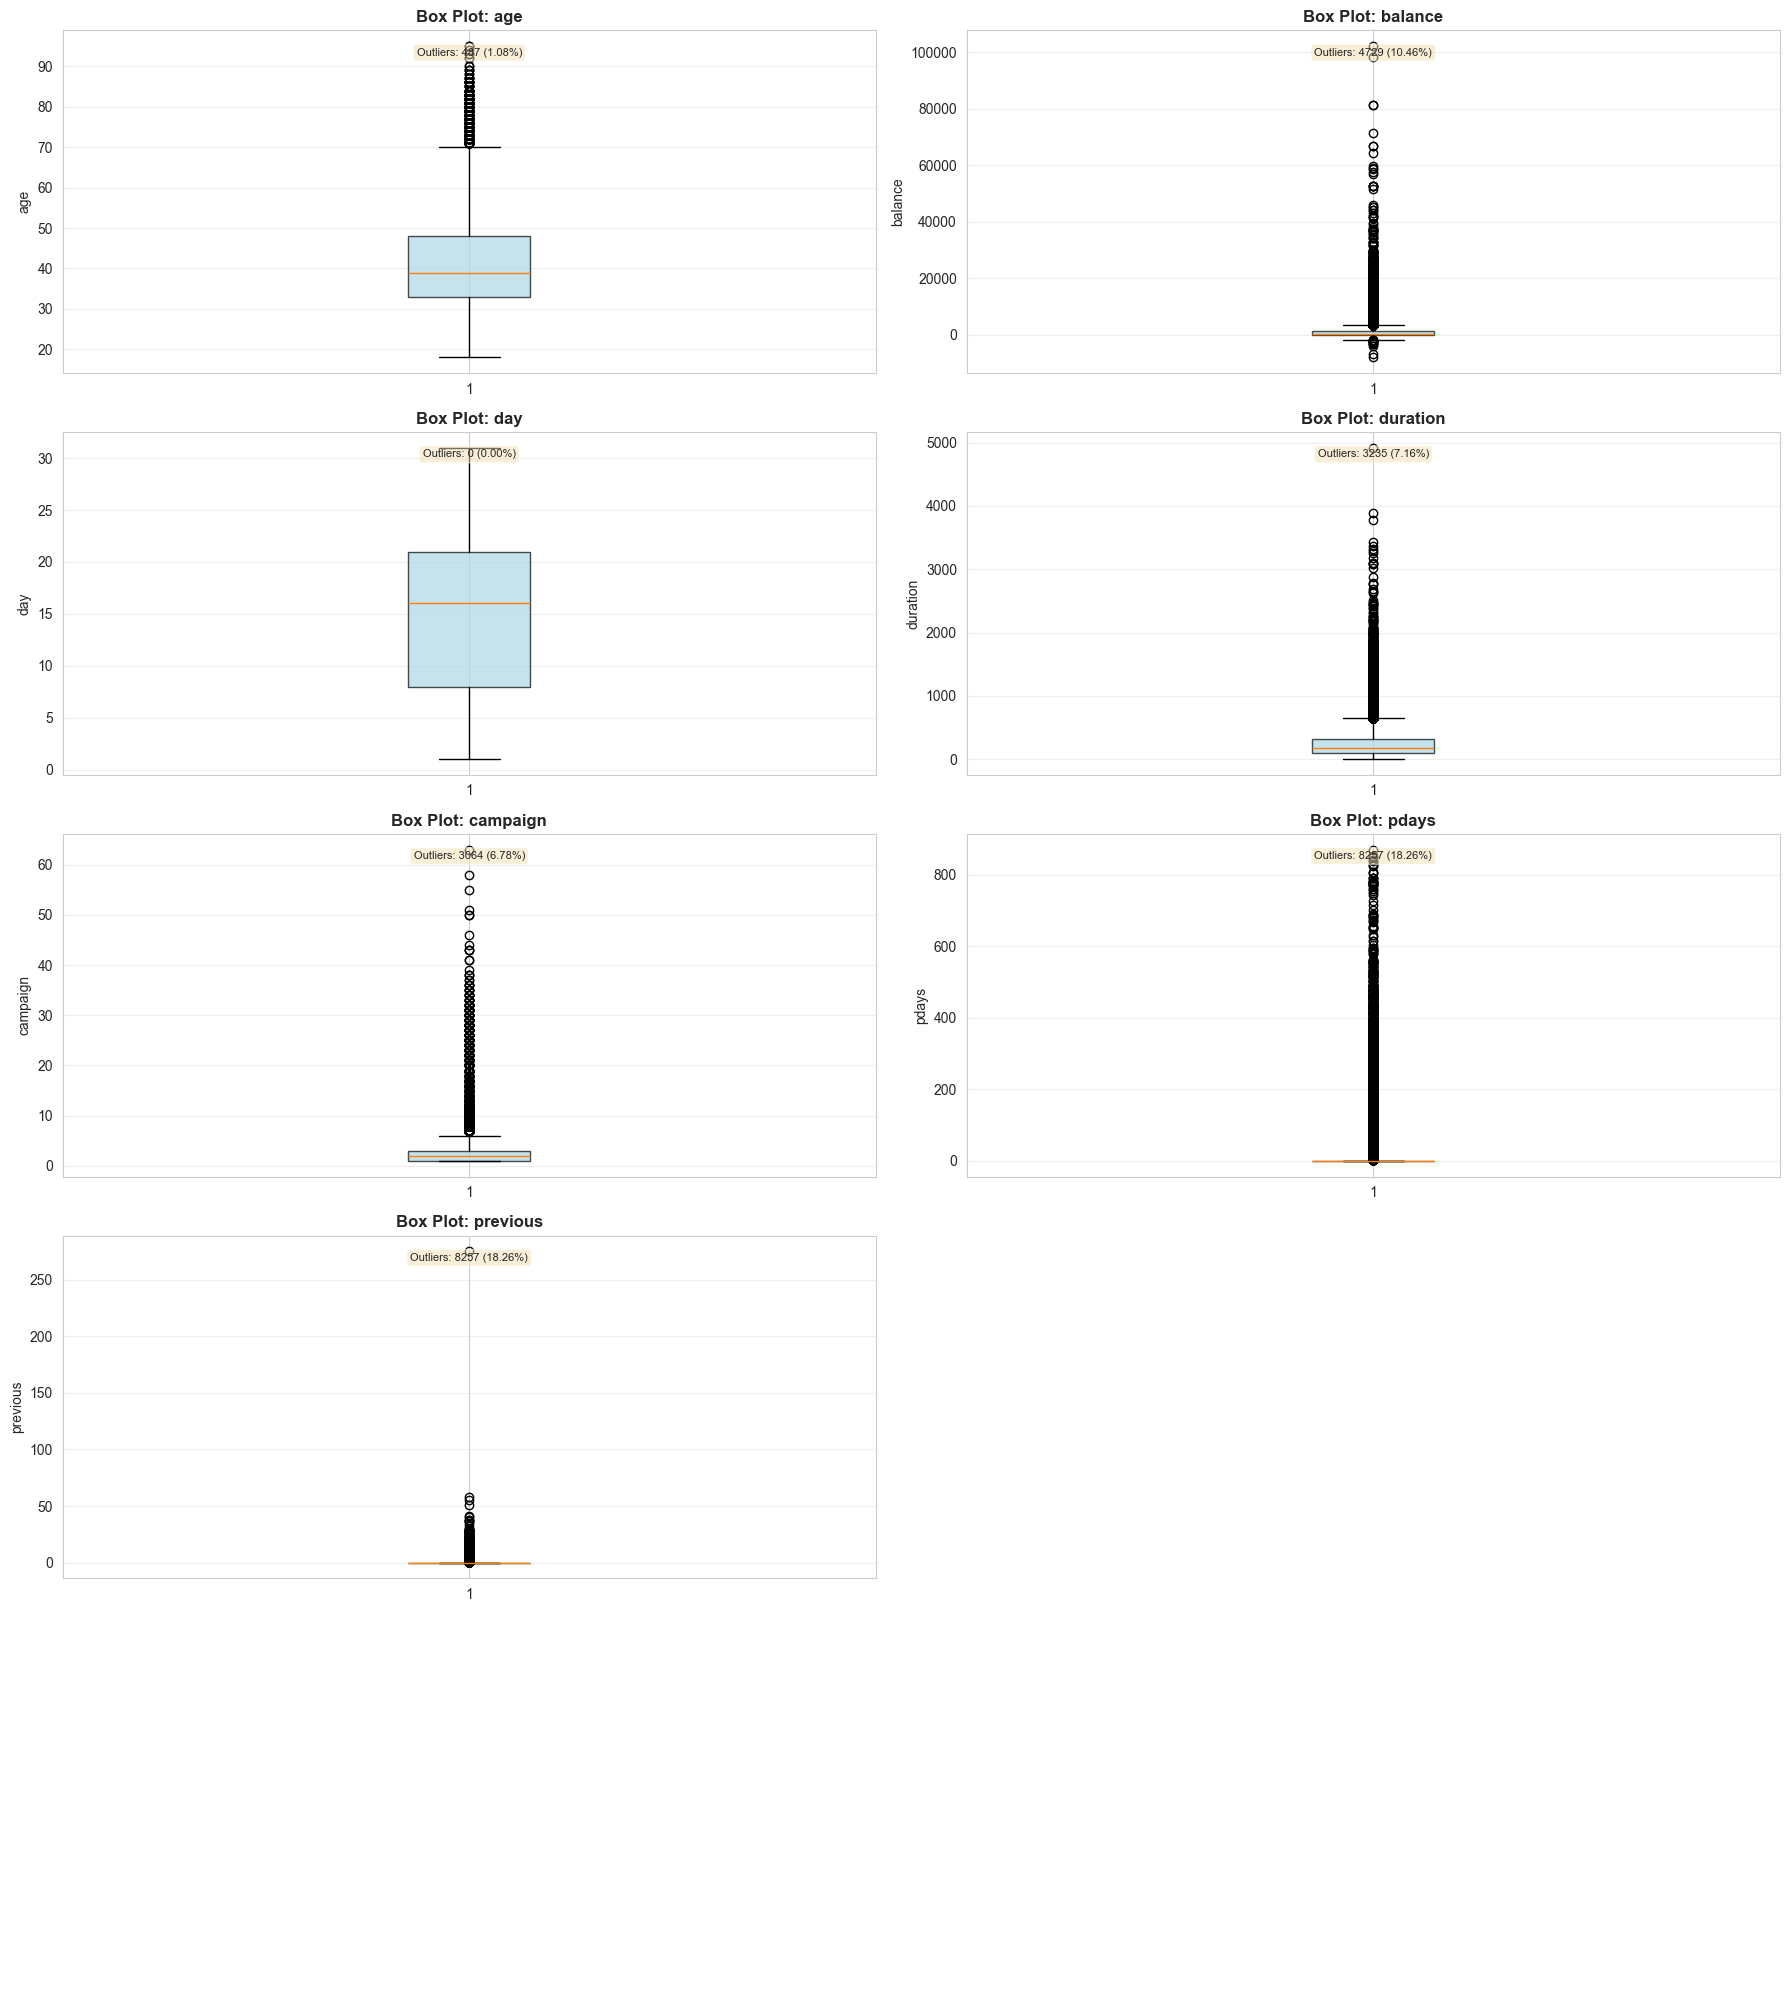

✅ Box plots completed!

📊 2.5: Generating scatter plot matrix (pairwise relationships)...


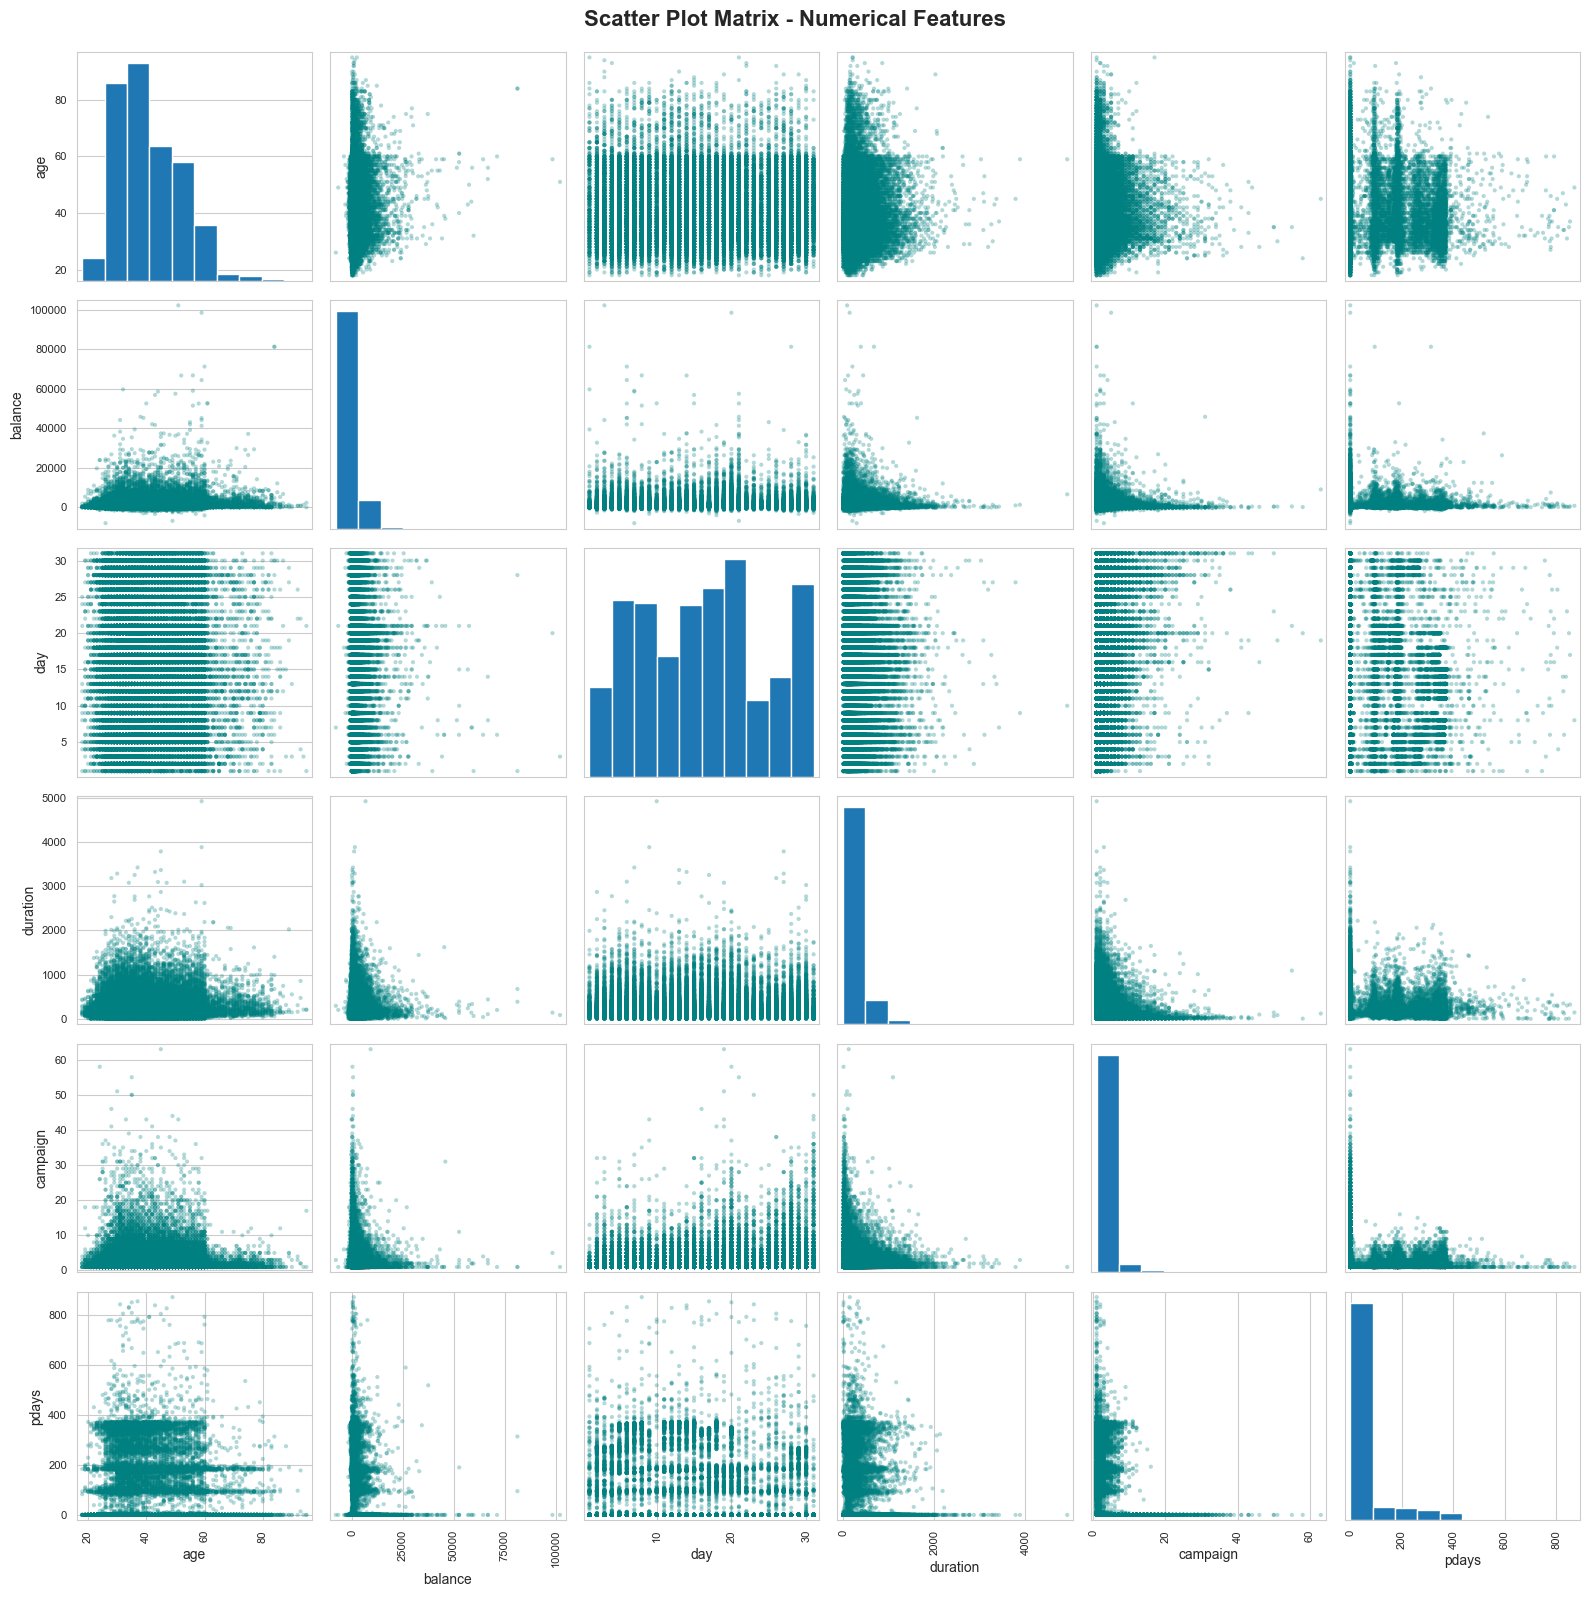

✅ Scatter plots completed!



In [3]:
# ======================================================================================
# REQUIREMENT 2: VISUAL DATA EXPLORATION (Score: 6)
# ======================================================================================
print("=" * 120)
print(" REQUIREMENT 2: VISUAL DATA EXPLORATION ".center(120, "="))
print("=" * 120)

# 2.1: Distribution of Numerical Features (Histograms)
print("\n📊 2.1: Generating histograms for numerical features...")
n_num = len(numerical_features)
n_cols = 3
n_rows = (n_num + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numerical_features):
    ax = axes[idx]
    df[col].hist(bins=30, ax=ax, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    ax.legend(fontsize=8)

for idx in range(n_num, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✅ Histograms completed!\n")

# 2.2: Distribution of Categorical Features (Bar Graphs)
print("📊 2.2: Generating bar graphs for categorical features...")
n_cat = len(categorical_features)
n_cols = 2
n_rows = (n_cat + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(categorical_features):
    ax = axes[idx]
    value_counts = df[col].value_counts().head(15)
    value_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    total = len(df[col])
    for i, (category, count) in enumerate(value_counts.items()):
        percentage = (count / total) * 100
        ax.text(i, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=8)

for idx in range(n_cat, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✅ Bar graphs completed!\n")

# 2.3: Correlation Heatmap
print("📊 2.3: Generating correlation heatmap...")
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\n🔍 Highly Correlated Feature Pairs (|correlation| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
    display(high_corr_df)
else:
    print("No highly correlated pairs found (threshold: |0.7|)")
print("✅ Correlation analysis completed!\n")

# 2.4: Box Plots for Outlier Detection
print("📊 2.4: Generating box plots for outlier detection...")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numerical_features):
    ax = axes[idx]
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    ax.text(0.5, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)', 
            transform=ax.transAxes, ha='center', va='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)

for idx in range(n_num, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✅ Box plots completed!\n")

# 2.5: Scatter Plot Matrix for numerical features (sample)
print("📊 2.5: Generating scatter plot matrix (pairwise relationships)...")
if len(numerical_features) <= 6:
    scatter_features = numerical_features
else:
    scatter_features = numerical_features[:6]  # Limit to first 6 for readability

scatter_plot = pd.plotting.scatter_matrix(df[scatter_features], figsize=(16, 16), 
                                         alpha=0.3, diagonal='hist', color='teal')
plt.suptitle('Scatter Plot Matrix - Numerical Features', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
print("✅ Scatter plots completed!\n")


In [4]:
# ======================================================================================
# REQUIREMENT 3: HANDLING MISSING VALUES (Score: 3)
# ======================================================================================
print("=" * 120)
print(" REQUIREMENT 3: HANDLING MISSING VALUES ".center(120, "="))
print("=" * 120)

# 3.1: Identify missing values
print("\n🔍 3.1: IDENTIFYING MISSING VALUES")
print("-" * 120)

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
).reset_index(drop=True)

if len(missing_data) == 0:
    print("✅ EXCELLENT! No missing values found in the dataset.")
    print(f"   Total features: {len(df.columns)}")
    print(f"   Total records: {len(df)}")
else:
    print(f"⚠️ Missing values detected in {len(missing_data)} feature(s):\n")
    display(missing_data)
    
    # Visualize missing values
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].barh(missing_data['Feature'], missing_data['Missing_Percentage'], 
                 color='#E74C3C', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    for i, (feat, pct) in enumerate(zip(missing_data['Feature'], missing_data['Missing_Percentage'])):
        axes[0].text(pct, i, f' {pct:.2f}%', va='center', fontsize=10)
    
    missing_matrix = df[missing_data['Feature']].isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap='Reds', cbar=True, ax=axes[1], 
               yticklabels=missing_data['Feature'])
    axes[1].set_title('Missing Values Pattern', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Record Index', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# 3.2: Apply appropriate handling strategies
print("\n🔧 3.2: APPLYING HANDLING STRATEGIES")
print("-" * 120)

df_cleaned = df.copy()
handling_log = []

if len(missing_data) > 0:
    for idx, row in missing_data.iterrows():
        feature = row['Feature']
        missing_pct = row['Missing_Percentage']
        data_type = row['Data_Type']
        
        print(f"\n📌 Feature: {feature} | Missing: {missing_pct:.2f}% | Type: {data_type}")
        
        if missing_pct > 50:
            df_cleaned = df_cleaned.drop(columns=[feature])
            strategy = "DROPPED (>50% missing)"
        elif data_type in ['int64', 'float64']:
            median_value = df_cleaned[feature].median()
            df_cleaned[feature].fillna(median_value, inplace=True)
            strategy = f"IMPUTED with MEDIAN ({median_value:.2f})"
        else:
            mode_value = df_cleaned[feature].mode()[0] if not df_cleaned[feature].mode().empty else "Unknown"
            df_cleaned[feature].fillna(mode_value, inplace=True)
            strategy = f"IMPUTED with MODE ('{mode_value}')"
        
        print(f"   ✓ Strategy Applied: {strategy}")
        handling_log.append({
            'Feature': feature,
            'Missing_%': missing_pct,
            'Data_Type': data_type,
            'Strategy': strategy
        })
    
    print("\n" + "=" * 120)
    print("HANDLING STRATEGIES SUMMARY:")
    handling_df = pd.DataFrame(handling_log)
    display(handling_df)
else:
    print("No handling strategies needed - dataset is complete!")

# 3.3: Justification
print("\n📝 3.3: JUSTIFICATION FOR CHOSEN APPROACH")
print("-" * 120)
print("""
STRATEGY RATIONALE:

1. REMOVAL (>50% missing): Features with excessive missingness provide limited information 
   and may introduce bias. Dropping is the most appropriate action.

2. MEDIAN IMPUTATION (Numerical): Median is robust to outliers and maintains distribution 
   integrity better than mean for skewed data. Preserves central tendency.

3. MODE IMPUTATION (Categorical): Most frequent value represents dominant pattern, 
   maintaining data consistency and minimizing distortion.

4. ALTERNATIVE METHODS (for consideration):
   • Advanced: KNN imputation, MICE (Multivariate Imputation by Chained Equations)
   • Predictive: Using machine learning models to predict missing values
   • Domain-specific: Business logic-based imputation
   • Indicator variables: Flagging missingness when it may be informative

The chosen strategies balance simplicity, effectiveness, and interpretability for 
exploratory data analysis and preprocessing for supervised learning tasks.
""")

remaining_missing = df_cleaned.isnull().sum().sum()
print(f"✅ Verification: Missing values after handling = {remaining_missing}")
print(f"   Original shape: {df.shape} → Cleaned shape: {df_cleaned.shape}")
print("=" * 120 + "\n")


======================================== REQUIREMENT 3: HANDLING MISSING VALUES ========================================

🔍 3.1: IDENTIFYING MISSING VALUES
------------------------------------------------------------------------------------------------------------------------
✅ EXCELLENT! No missing values found in the dataset.
   Total features: 17
   Total records: 45211

🔧 3.2: APPLYING HANDLING STRATEGIES
------------------------------------------------------------------------------------------------------------------------
No handling strategies needed - dataset is complete!

📝 3.3: JUSTIFICATION FOR CHOSEN APPROACH
------------------------------------------------------------------------------------------------------------------------

STRATEGY RATIONALE:

1. REMOVAL (>50% missing): Features with excessive missingness provide limited information 
   and may introduce bias. Dropping is the most appropriate action.

2. MEDIAN IMPUTATION (Numerical): Median is robust to outliers and 

In [5]:
# ======================================================================================
# REQUIREMENT 4: STATISTICAL CHARACTERIZATION OF NUMERICAL DATA (Score: 5)
# ======================================================================================
print("=" * 120)
print(" REQUIREMENT 4: STATISTICAL CHARACTERIZATION OF NUMERICAL DATA ".center(120, "="))
print("=" * 120)

# Update numerical features list after cleaning
numerical_features_cleaned = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Compute comprehensive descriptive statistics
print("\n📊 COMPREHENSIVE DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES")
print("-" * 120)

stats_data = []
for col in numerical_features_cleaned:
    data = df_cleaned[col].dropna()
    
    stats_data.append({
        'Feature': col,
        'Count': len(data),
        'Mean': data.mean(),
        'Median': data.median(),
        'Std_Dev': data.std(),
        'Variance': data.var(),
        'Min': data.min(),
        'Q1 (25%)': data.quantile(0.25),
        'Q3 (75%)': data.quantile(0.75),
        'Max': data.max(),
        'Range': data.max() - data.min(),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Skewness': data.skew(),
        'Kurtosis': data.kurtosis()
    })

stats_df = pd.DataFrame(stats_data)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

display(stats_df)

# Statistical insights
print("\n" + "=" * 120)
print("📈 STATISTICAL INSIGHTS & INTERPRETATIONS")
print("=" * 120)

for idx, row in stats_df.iterrows():
    print(f"\n📊 {row['Feature']}:")
    print(f"   • Central Tendency: Mean={row['Mean']:.4f}, Median={row['Median']:.4f}")
    print(f"   • Dispersion: Std Dev={row['Std_Dev']:.4f}, Variance={row['Variance']:.4f}, Range={row['Range']:.4f}, IQR={row['IQR']:.4f}")
    
    if abs(row['Skewness']) < 0.5:
        skew_interp = "approximately symmetric distribution"
    elif row['Skewness'] > 0.5:
        skew_interp = "right-skewed"
    else:
        skew_interp = "left-skewed"
    
    if abs(row['Kurtosis']) < 1:
        kurt_interp = "mesokurtic"
    elif row['Kurtosis'] > 1:
        kurt_interp = "leptokurtic"
    else:
        kurt_interp = "platykurtic"
    
    print(f"   • Shape Interpretation: {skew_interp}")
    print(f"   • Tail Behavior: {kurt_interp}")
    
    Q1 = row['Q1 (25%)']
    Q3 = row['Q3 (75%)']
    IQR = row['IQR']
    outlier_count = len(df_cleaned[(df_cleaned[row['Feature']] < Q1 - 1.5*IQR) | 
                                    (df_cleaned[row['Feature']] > Q3 + 1.5*IQR)])
    outlier_pct = (outlier_count / row['Count']) * 100
    print(f"   • Outliers (IQR method): {outlier_count} ({outlier_pct:.2f}% of data)")

print("\n" + "=" * 120)
print(" ALL REQUIREMENTS COMPLETED SUCCESSFULLY ".center(120, "="))
print("=" * 120)
print(f"""
✅ Requirement 1: Features Identification and Summary - COMPLETE
✅ Requirement 2: Visual Data Exploration - COMPLETE
✅ Requirement 3: Handling Missing Values - COMPLETE
✅ Requirement 4: Statistical Characterization - COMPLETE

Dataset Summary:
- Original Shape: {df.shape}
- Cleaned Shape: {df_cleaned.shape}
- Numerical Features: {len(numerical_features_cleaned)}
- Categorical Features: {len(df_cleaned.select_dtypes(include=['object']).columns)}
- Total Missing Values After Cleaning: {df_cleaned.isnull().sum().sum()}
""")


============================ REQUIREMENT 4: STATISTICAL CHARACTERIZATION OF NUMERICAL DATA =============================

📊 COMPREHENSIVE DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES
------------------------------------------------------------------------------------------------------------------------


,Feature,Count,Mean,Median,Std_Dev,Variance,Min,Q1 (25%),Q3 (75%),Max,Range,IQR,Skewness,Kurtosis
0,age,45211,40.9362,39.0,10.6188,1.1276e+02,18,33.0,48.0,95,77,15.0,0.6848,0.3196
1,balance,45211,1362.2721,448.0,3044.7658,9.2706e+06,-8019,72.0,1428.0,102127,110146,1356.0,8.3603,140.7515
2,day,45211,15.8064,16.0,8.3225,6.9264e+01,1,8.0,21.0,31,30,13.0,0.0931,-1.0599
3,duration,45211,258.1631,180.0,257.5278,6.6321e+04,0,103.0,319.0,4918,4918,216.0,3.1443,18.1539
4,campaign,45211,2.7638,2.0,3.0980,9.5977e+00,1,1.0,3.0,63,62,2.0,4.8987,39.2497
5,pdays,45211,40.1978,-1.0,100.1287,1.0026e+04,-1,-1.0,-1.0,871,872,0.0,2.6157,6.9352
6,previous,45211,0.5803,0.0,2.3034,5.3058e+00,0,0.0,0.0,275,275,0.0,41.8465,4506.8607



📈 STATISTICAL INSIGHTS & INTERPRETATIONS

📊 age:
   • Central Tendency: Mean=40.9362, Median=39.0000
   • Dispersion: Std Dev=10.6188, Variance=112.7581, Range=77.0000, IQR=15.0000
   • Shape Interpretation: right-skewed
   • Tail Behavior: mesokurtic
   • Outliers (IQR method): 487 (1.08% of data)

📊 balance:
   • Central Tendency: Mean=1362.2721, Median=448.0000
   • Dispersion: Std Dev=3044.7658, Variance=9270598.9545, Range=110146.0000, IQR=1356.0000
   • Shape Interpretation: right-skewed
   • Tail Behavior: leptokurtic
   • Outliers (IQR method): 4729 (10.46% of data)

📊 day:
   • Central Tendency: Mean=15.8064, Median=16.0000
   • Dispersion: Std Dev=8.3225, Variance=69.2636, Range=30.0000, IQR=13.0000
   • Shape Interpretation: approximately symmetric distribution
   • Tail Behavior: platykurtic
   • Outliers (IQR method): 0 (0.00% of data)

📊 duration:
   • Central Tendency: Mean=258.1631, Median=180.0000
   • Dispersion: Std Dev=257.5278, Variance=66320.5741, Range=4918.0000

In [6]:
df_cleaned.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df_cleaned.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [8]:
df_cleaned['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

# Section 3: Model Implementation Requirements 

**Objective:** The model implementation phase defines the procedures and constraints that govern the design, training,
validation, and testing of a simple neural network.
implementation must be carried out entirely from first principles, making use only of fundamental
scientific libraries such as NumPy for matrix operations and Matplotlib for visualization

In [9]:
# Prepare data for the numpy-based neural network:
data = df_cleaned.copy()
# Ensure target is numeric (0/1)
if data['y'].dtype == 'object' or data['y'].dtype == 'bool':
    data['y'] = data['y'].map({'no': 0, 'yes': 1})

# Separate features and target as a DataFrame (X_df) and numpy array (y)
X_df = data.drop(columns='y').copy()
y = data['y'].values.reshape(-1, 1)

# Identify categorical columns and one-hot encode them (drop_first to avoid collinearity)
categorical_cols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()
if len(categorical_cols) > 0:
    X_encoded = pd.get_dummies(X_df, columns=categorical_cols, drop_first=True)
else:
    X_encoded = X_df.copy()

# Convert to float and handle any remaining non-numeric columns defensively
# (this will raise a clear error if a column cannot be converted)
X_encoded = X_encoded.apply(pd.to_numeric, errors='raise')

# Standardize numeric features (zero mean, unit variance). Avoid division by zero.
means = X_encoded.mean()
stds = X_encoded.std(ddof=0).replace(0, 1)
X_scaled = (X_encoded - means) / stds

# Final training matrix: numpy array of shape (m, n_features)
X = X_scaled.values.astype(float)

# Print shapes to confirm
m, n_features = X.shape
print(f"Total samples (m): {m}")
print(f"Number of features (N): {n_features}")

Total samples (m): 45211
Number of features (N): 42


In [10]:
# Data Partitioning

np.random.seed(42)  # for reproducibility
indices = np.random.permutation(m)

# 70 / 20 / 10 split
train_end = int(0.7 * m)
val_end   = int(0.9 * m)  # 70% + 20% = 90%

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("\nSPLIT SUMMARY:")
print("-" * 120)
print(f"Train set:      {X_train.shape[0]} samples ({X_train.shape[0] / m * 100:.2f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0] / m * 100:.2f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0] / m * 100:.2f}%)")
print("-" * 120)


SPLIT SUMMARY:
------------------------------------------------------------------------------------------------------------------------
Train set:      31647 samples (70.00%)
Validation set: 9042 samples (20.00%)
Test set:       4522 samples (10.00%)
------------------------------------------------------------------------------------------------------------------------


In [11]:
# Batching

def create_mini_batches(X, y, batch_size=100, shuffle=True):
    """
    Splits (X, y) into mini-batches of size 'batch_size'.
    - If the number of samples is not divisible by batch_size,
      the last batch will contain the remaining samples.
    - If shuffle=True, data is randomly shuffled before batching.
    """
    m = X.shape[0]
    
    if shuffle:
        perm = np.random.permutation(m)
        X_shuffled = X[perm]
        y_shuffled = y[perm]
    else:
        X_shuffled = X
        y_shuffled = y
    
    mini_batches = []
    for start_idx in range(0, m, batch_size):
        end_idx = start_idx + batch_size
        X_batch = X_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]
        mini_batches.append((X_batch, y_batch))
    
    return mini_batches

# Create mini-batches for the training set
batch_size = 100
train_batches = create_mini_batches(X_train, y_train, batch_size=batch_size, shuffle=True)

print("\nBATCHING SUMMARY:")
print("-" * 120)
print(f"Total training samples: {X_train.shape[0]}")
print(f"Batch size:             {batch_size}")
print(f"Number of mini-batches: {len(train_batches)}")

# Inspect the first and last batch sizes
first_batch_X, first_batch_y = train_batches[0]
last_batch_X, last_batch_y   = train_batches[-1]

print(f"\nFirst batch size: {first_batch_X.shape[0]} samples")
print(f"Last  batch size: {last_batch_X.shape[0]} samples")
print("-" * 120)



BATCHING SUMMARY:
------------------------------------------------------------------------------------------------------------------------
Total training samples: 31647
Batch size:             100
Number of mini-batches: 317

First batch size: 100 samples
Last  batch size: 47 samples
------------------------------------------------------------------------------------------------------------------------


In [12]:
# Training Epochs

batch_size = 100
num_epochs = 10  # minimum required

# Number of training samples
m_train = X_train.shape[0]

# Number of batches (iterations) per epoch
num_batches_per_epoch = int(np.ceil(m_train / batch_size))

# Total iterations over all epochs
total_iterations = num_epochs * num_batches_per_epoch

print("Training Data Size:", m_train)
print("Batch Size:", batch_size)
print("Number of Epochs:", num_epochs)
print("Batches Per Epoch:", num_batches_per_epoch)
print("Total Training Iterations:", total_iterations)


Training Data Size: 31647
Batch Size: 100
Number of Epochs: 10
Batches Per Epoch: 317
Total Training Iterations: 3170


In [13]:
# Network Architecture


# Activation Functions

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)



# Weight Initialization

def initialize_parameters(N_input):

    np.random.seed(42)  # to ensure reproducibility

    W1 = np.random.randn(10, N_input) * 0.01   # small random values
    b1 = np.zeros((10, 1))                     # bias vector for hidden layer

    W2 = np.random.randn(1, 10) * 0.01         # weights from hidden → output neuron
    b2 = np.zeros((1, 1))                      # bias for the single output neuron

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}




# Initialize Parameters Using Training Data

N = X_train.shape[1]   # <-- Number of features after preprocessing
params = initialize_parameters(N)

print("📌 Model architecture initialized successfully!")
print(f"Input features (N): {N}")
print(f"W1 shape: {params['W1'].shape}")
print(f"b1 shape: {params['b1'].shape}")
print(f"W2 shape: {params['W2'].shape}")
print(f"b2 shape: {params['b2'].shape}")

📌 Model architecture initialized successfully!
Input features (N): 42
W1 shape: (10, 42)
b1 shape: (10, 1)
W2 shape: (1, 10)
b2 shape: (1, 1)


In [14]:
# Requirement Error Calculation Function

def error_Cyberbullying(actual_outputs_vector, target_output_vector):
    """
    Error Calculation Function
    --------------------------
    Computes sample-wise classification errors (0 = correct, 1 = misclassified)
    and the aggregated error as the mean misclassification rate.

    This is consistent with the requirement that:
        accuracy_TeamName = 1 - aggregated_error
    """
    # Ensure shape (1, m) for both
    if target_output_vector.ndim == 1:
        target_output_vector = target_output_vector.reshape(1, -1)
    if actual_outputs_vector.ndim == 1:
        actual_outputs_vector = actual_outputs_vector.reshape(1, -1)

    # Convert probabilities to class labels (binary)
    predicted_labels = (actual_outputs_vector >= 0.5).astype(int)

    # Error vector: 1 if misclassified, 0 if correct
    error_vector = (predicted_labels != target_output_vector).astype(int)

    # Aggregated error: misclassification rate
    error = np.mean(error_vector)

    return error_vector, error




In [15]:
def accuracy_Cyberbullying(actual_outputs_vector, target_output_vector):
    """
    Accuracy Evaluation Function
    ----------------------------
    Uses the error_TeamName function and returns:
        accuracy = 1 - aggregated_error
    ensuring the required relationship holds.
    """
    _, error = error_Cyberbullying(actual_outputs_vector, target_output_vector)
    accuracy = 1.0 - error
    return accuracy

In [16]:
# Requirement Forward Pass Subroutine & Validation Function

# -------------------------------------------------------------------------
# 1. FORWARD PASS SUBROUTINE
# Requirement Description: Propagates the input data through the network layers 
# to compute the predicted outputs. (From Training Procedure Req)
# -------------------------------------------------------------------------
def forward_propagation(X, parameters):
    """
    Argument:
    X -- Input data of size (number of features, number of examples)
    parameters -- python dictionary containing your parameters (W1, b1, W2, b2)
    
    Returns:
    A2 -- The sigmoid output of the second activation
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"
    """
    # Retrieve parameters
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # --- Layer 1 (Hidden Layer) ---
    # Z1 = W1 . X + b1
    Z1 = np.dot(W1, X) + b1
    # A1 = ReLU(Z1)
    A1 = relu(Z1)
    
    # --- Layer 2 (Output Layer) ---
    # Z2 = W2 . A1 + b2
    Z2 = np.dot(W2, A1) + b2
    # A2 = Sigmoid(Z2)
    A2 = sigmoid(Z2)
    
    # Cache values for Backpropagation
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    
    return A2, cache



def test_ValidationSet_Cyberbullying(labeled_input_matrix, weights_matrix):
    """
    Computes the error of the network on the validation set.
    
    Arguments:
    labeled_input_matrix -- Tuple containing (X_val, y_val)
    weights_matrix -- Python dictionary containing parameters
    
    Returns:
    Error_Vector -- The set of individual errors for each sample.
    Error -- Aggregated error (Mean Squared Error).
    """
    # Unpack input
    X_input, y_target = labeled_input_matrix
    
    # Dimension Handling: Ensure X is (features, samples)
    # If X is (samples, features) [e.g. (9042, 16)], transpose it to (16, 9042)
    if X_input.shape[0] != weights_matrix['W1'].shape[1]:
        X_input = X_input.T
        
    # Ensure y_target is (1, samples)
    if y_target.ndim == 1:
        y_target = y_target.reshape(1, -1)
        
    # --- FORWARD PASS ---
    # [cite_start]Now we use the subroutine we defined above [cite: 30]
    A2, _ = forward_propagation(X_input, weights_matrix)
    
    # --- ERROR CALCULATION ---
    # Compare predictions (A2) with targets (y_target)
    Error_Vector, Error = error_Cyberbullying(A2, y_target)
    
    return Error_Vector, Error





In [17]:
# Requirement Testing Function

def test_TestSet_Cyberbullying(labeled_input_matrix, weights_matrix):
    """
    Evaluates the final trained network on the independent test set.
    Executed only once after training is complete.
    
    Arguments:
    labeled_input_matrix -- A tuple containing (X_test, y_test)
                            X_test: Test set features
                            y_test: Test set labels
    weights_matrix -- Python dictionary containing the final trained parameters (W1, b1, W2, b2)
    
    Returns:
    Error_Vector -- The set of individual errors for each sample.
    Error -- Aggregated error (Mean Squared Error).
    """
    
    # Unpack the test data
    X_test, y_test = labeled_input_matrix
    
    # --- Dimension Check ---
    # Ensure X_test is (features, samples) to match W1 (neurons, features)
    if X_test.shape[0] != weights_matrix['W1'].shape[1]:
        X_test = X_test.T
        
    # Ensure y_test is (1, samples) for correct subtraction
    if y_test.ndim == 1:
        y_test = y_test.reshape(1, -1)
        
    # 1. Forward Propagation
    # Compute the final predictions of the network on the test set
    # We only need A2 (output), we discard the cache
    A2, _ = forward_propagation(X_test, weights_matrix)
    
    # 2. Error Calculation
    # Compute the error using the previously defined helper function
    Error_Vector, Error = error_Cyberbullying(A2, y_test)
    
    return Error_Vector, Error

In [18]:
# Requirement Training Procedure (Backpropagation)

def backward_propagation(X, Y, cache, parameters):
    """
    Propagates the error backward, computes gradients.
    
    Arguments:
    X -- Input data (features, samples)
    Y -- True labels (1, samples)
    cache -- dictionary containing Z1, A1, Z2, A2 from forward_propagation
    parameters -- dictionary containing W1, b1, W2, b2
    
    Returns:
    grads -- dictionary containing gradients dW1, db1, dW2, db2
    """
    m = X.shape[1]  # Number of samples
    
    # Retrieve internals from cache
    A1 = cache["A1"]
    A2 = cache["A2"]
    W2 = parameters["W2"]
    Z1 = cache["Z1"] # Needed for ReLU derivative
    
    # --- Output Layer Gradients (Layer 2) ---
    # Derivative of MSE Loss with Sigmoid activation
    # dL/dA2 = (A2 - Y)
    # dA2/dZ2 = A2 * (1 - A2) (Sigmoid derivative)
    # Chain rule: dZ2 = (A2 - Y) * A2 * (1 - A2)
    
    # Note: If we used Cross-Entropy, dZ2 would just be (A2 - Y). 
    # Since we are strictly using the MSE Error definition from earlier:
    dZ2 = (A2 - Y) * sigmoid_derivative(A2)
    
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # --- Hidden Layer Gradients (Layer 1) ---
    # dA1 = W2.T * dZ2
    dA1 = np.dot(W2.T, dZ2)
    
    # dZ1 = dA1 * relu_derivative(Z1)
    dZ1 = dA1 * relu_derivative(Z1)
    
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    
    return grads


def update_parameters(parameters, grads, learning_rate=0.1):
    """
    Updates parameters using gradient descent.
    
    Arguments:
    parameters -- python dictionary containing W1, b1, W2, b2
    grads -- python dictionary containing dW1, db1, dW2, db2
    learning_rate -- step size for learning
    
    Returns:
    parameters -- python dictionary containing updated parameters
    """
    # Retrieve parameters
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # Retrieve gradients
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    
    # Update rule: W = W - alpha * dW
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    
    return parameters


Parameter shapes and types:
W1: type=<class 'numpy.ndarray'>, shape=(10, 42)
b1: type=<class 'numpy.ndarray'>, shape=(10, 1)
W2: type=<class 'numpy.ndarray'>, shape=(1, 10)
b2: type=<class 'numpy.ndarray'>, shape=(1, 1)

Starting training for 20 epochs...
--------------------------------------------------------------------------------
Epoch      | Train Loss   | Train Acc    | Val Loss     | Val Acc     
--------------------------------------------------------------------------------


1          | 0.117294     | 0.8827       | 0.116235     | 0.8838
2          | 0.117294     | 0.8827       | 0.116235     | 0.8838
3          | 0.117294     | 0.8827       | 0.116235     | 0.8838
4          | 0.117294     | 0.8827       | 0.116235     | 0.8838
5          | 0.117294     | 0.8827       | 0.116235     | 0.8838
6          | 0.117325     | 0.8827       | 0.116235     | 0.8838
7          | 0.104749     | 0.8953       | 0.135844     | 0.8963
8          | 0.101874     | 0.8981       | 0.150784     | 0.8998
9          | 0.099314     | 0.9007       | 0.157235     | 0.9027
10         | 0.098714     | 0.9013       | 0.161734     | 0.9032
11         | 0.097829     | 0.9022       | 0.164110     | 0.9046
12         | 0.098240     | 0.9018       | 0.165893     | 0.9047
13         | 0.097987     | 0.9020       | 0.166827     | 0.9041
14         | 0.097956     | 0.9020       | 0.167845     | 0.9037
15         | 0.097703     | 0.9023       | 0.166317     | 0.9046
16         | 0.097703    

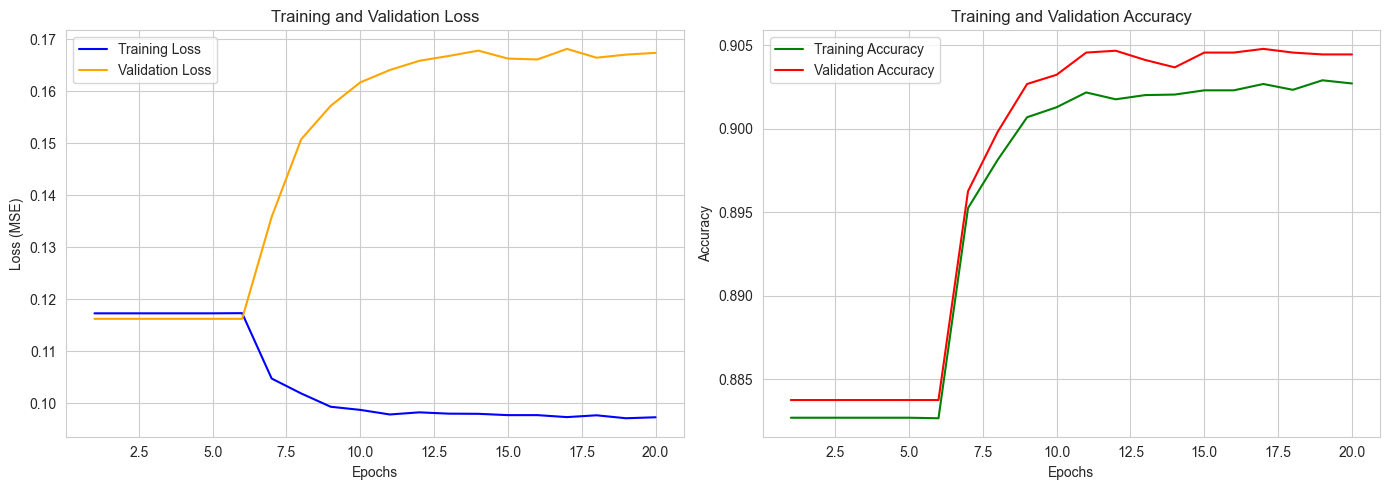


FINAL TESTING EVALUATION
------------------------------
Final Test Loss (MSE):  0.164514
Final Test Accuracy:    90.4909%
------------------------------


In [19]:
# Debug: Check parameter types
print("\nParameter shapes and types:")
for key, val in params.items():
    print(f"{key}: type={type(val)}, shape={val.shape if hasattr(val, 'shape') else 'N/A'}")

# --- TRAINING PROCEDURE ---

# Hyperparameters
learning_rate = 0.1
num_epochs = 20

# History tracking
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print(f"\nStarting training for {num_epochs} epochs...")
print("-" * 80)
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<12} | {'Val Loss':<12} | {'Val Acc':<12}")
print("-" * 80)

for i in range(num_epochs):
    
    # 1. Shuffle and Batch
    train_batches = create_mini_batches(X_train, y_train, batch_size=100, shuffle=True)
    
    # 2. Mini-batch Gradient Descent
    for batch in train_batches:
        (batch_X, batch_y) = batch
        
        # Transpose to match network shape (features, batch_size)
        batch_X = batch_X.T
        batch_y = batch_y.reshape(1, -1)
        
        # Forward
        A2, cache = forward_propagation(batch_X, params)
        
        # Backward
        grads = backward_propagation(batch_X, batch_y, cache, params)
        
        # Update
        params = update_parameters(params, grads, learning_rate)
        
    # 3. Evaluate after each epoch
    
    # Training Metrics (Full Set)
    train_A2, _ = forward_propagation(X_train.T, params)
    _, train_loss = error_Cyberbullying(train_A2, y_train.T) # y must be (1, m)
    train_acc = accuracy_Cyberbullying(train_A2, y_train.T)
    
    # Validation Metrics
    val_A2, _ = forward_propagation(X_val.T, params)
    _, val_loss = test_ValidationSet_Cyberbullying((X_val, y_val), params) # Uses the PDF req function
    val_acc = accuracy_Cyberbullying(val_A2, y_val.T)
    
    # Store history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"{i+1:<10} | {train_loss:.6f}     | {train_acc:.4f}       | {val_loss:.6f}     | {val_acc:.4f}")

print("-" * 80)

# --- REPORTING & VISUALIZATION ---

epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label='Training Loss', color='blue')
plt.plot(epochs_range, history["val_loss"], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label='Training Accuracy', color='green')
plt.plot(epochs_range, history["val_acc"], label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- FINAL TESTING ---
print("\nFINAL TESTING EVALUATION")
print("-" * 30)
# Use the required Testing Function
_, test_loss = test_TestSet_Cyberbullying((X_test, y_test), params)

# Calculate Test Accuracy manually for reporting
test_A2, _ = forward_propagation(X_test.T, params)
test_acc = accuracy_Cyberbullying(test_A2, y_test.T)

print(f"Final Test Loss (MSE):  {test_loss:.6f}")
print(f"Final Test Accuracy:    {test_acc:.4%}")
print("-" * 30)